# Lab: k-Nearest Neighbors (KNN) with scikit-learn

In the [theory notes](./17_knn_theory.md), we learned that KNN classifies a new point by finding its **k nearest neighbors** in feature space and taking a **majority vote**. In the [implementation file](./18_knn_implementation.py), we built KNN from scratch — computing Euclidean distances, sorting, and voting manually.

**Now it's time to use the real thing.** scikit-learn's `KNeighborsClassifier` handles the distance computations, neighbor selection, and voting for us. In this lab, we will learn how to:

1. Load and prepare a classification dataset (with **feature scaling** — mandatory for KNN).
2. Build and train a `KNeighborsClassifier`.
3. **Visualize the decision boundaries** produced by different values of `k`.
4. Understand the key hyperparameters (`n_neighbors`, `weights`, `metric`).
5. See how `k` controls the bias-variance trade-off.
6. Compare **uniform vs. distance weighting**.
7. Demonstrate **why feature scaling is critical** for KNN.

---

## 1. The Dataset

We'll use the **Iris dataset** — the same classic multi-class classification benchmark from earlier labs. The goal is to classify iris flowers into three species (*setosa*, *versicolor*, *virginica*) based on four petal/sepal measurements.

KNN is a great fit here because:
- The dataset is **small** (150 samples) — KNN stores all training data and computes distances at prediction time, so small datasets keep it fast.
- It's **low-dimensional** (4 features) — distance metrics work well in low dimensions (remember the Curse of Dimensionality from the theory).
- The classes have **clear geometric clusters** — KNN relies on the assumption that *"proximity equals similarity"*.

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset
iris = load_iris()

feature_names = list(iris.feature_names)
target_names = list(iris.target_names)

df = pd.DataFrame(iris.data, columns=feature_names)
df["species"] = [target_names[t] for t in iris.target]
df["target"] = iris.target

print(f"Dataset: {df.shape[0]} samples, {len(feature_names)} features")
print(f"Classes: {target_names}")
print(f"Class distribution:\n{df['species'].value_counts().to_string()}")
print()
df.sample(5, random_state=42)

Dataset: 150 samples, 4 features
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Class distribution:
species
setosa        50
versicolor    50
virginica     50



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
73,6.1,2.8,4.7,1.2,versicolor,1
18,5.7,3.8,1.7,0.3,setosa,0
118,7.7,2.6,6.9,2.3,virginica,2
78,6.0,2.9,4.5,1.5,versicolor,1
76,6.8,2.8,4.8,1.4,versicolor,1


---

## 2. Feature Scaling — Mandatory for KNN

This is the single most important preprocessing step for KNN. As the theory notes emphasize:

> *"This is the most important implementation detail. Because KNN calculates distances based on feature magnitudes, features with large ranges will dominate the calculation."*

KNN uses **Euclidean distance** to find neighbors. If one feature ranges from 0–7 (like petal length in cm) and another from 0–4.5 (like sepal width), the larger-range feature will have a disproportionate influence on the distance.

`StandardScaler` transforms each feature to zero mean and unit variance: $x_{\text{scaled}} = \frac{x - \mu}{\sigma}$

In [3]:
# Separate features and target
X = df[feature_names].values
y = df["target"].values

# Scale features — CRITICAL for KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  Feature means: {X.mean(axis=0).round(2)}")
print(f"  Feature stds:  {X.std(axis=0).round(2)}")
print()
print("After scaling:")
print(f"  Feature means: {X_scaled.mean(axis=0).round(2)}")
print(f"  Feature stds:  {X_scaled.std(axis=0).round(2)}")

Before scaling:
  Feature means: [5.84 3.06 3.76 1.2 ]
  Feature stds:  [0.83 0.43 1.76 0.76]

After scaling:
  Feature means: [-0. -0. -0. -0.]
  Feature stds:  [1. 1. 1. 1.]


---

## 3. Building a KNN Classifier

scikit-learn's `KNeighborsClassifier` is the main KNN class. Key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `n_neighbors` | Number of neighbors (k) to consider for voting | `5` |
| `weights` | How to weight neighbor votes: `"uniform"` (all equal) or `"distance"` (closer = more influence) | `"uniform"` |
| `metric` | Distance metric to use (`"euclidean"`, `"manhattan"`, etc.) | `"minkowski"` (p=2, i.e., Euclidean) |
| `algorithm` | Algorithm for neighbor search (`"auto"`, `"ball_tree"`, `"kd_tree"`, `"brute"`) | `"auto"` |

Remember from the theory: **KNN is a lazy learner** — calling `.fit()` doesn't learn parameters. It just *stores* the training data. All the real work happens during `.predict()`.

Let's train our first KNN model:

In [4]:
# Build a KNN classifier with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

print("KNN model ready!")
print(f"  n_neighbors (k): {knn.n_neighbors}")
print(f"  weights: {knn.weights}")
print(f"  metric: {knn.metric} (p={knn.p})")
print(f"  algorithm: {knn.algorithm}")
print(f"  Training samples stored: {knn.n_samples_fit_}")
print()
print("📌 Notice: .fit() didn't 'learn' anything — it just stored the 150 training points.")
print("   All the distance computation happens when we call .predict().")

KNN model ready!
  n_neighbors (k): 3
  weights: uniform
  metric: minkowski (p=2)
  algorithm: auto
  Training samples stored: 150

📌 Notice: .fit() didn't 'learn' anything — it just stored the 150 training points.
   All the distance computation happens when we call .predict().


---

## 4. Inspecting the Neighbors

One of the best things about KNN is its **transparency** — for any prediction, we can see *exactly* which training points influenced the decision. Let's pick a sample and inspect its neighbors:

In [5]:
# Pick a sample to inspect (index 75 — a versicolor flower)
sample_idx = 75
sample = X_scaled[sample_idx:sample_idx+1]

# Get the distances and indices of the k nearest neighbors
distances, indices = knn.kneighbors(sample)

print(f"Query point (index {sample_idx}): {target_names[y[sample_idx]]}")
print(f"Prediction: {target_names[knn.predict(sample)[0]]}")
print(f"\nThe {knn.n_neighbors} nearest neighbors:")
print(f"{'Rank':<6} {'Index':<8} {'Distance':<12} {'True Class':<15}")
print("-" * 41)
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    print(f"{rank:<6} {idx:<8} {dist:<12.4f} {target_names[y[idx]]:<15}")

print(f"\n📌 The 3 nearest neighbors vote: ", end="")
neighbor_classes = [target_names[y[idx]] for idx in indices[0]]
print(f"{neighbor_classes} → majority = {max(set(neighbor_classes), key=neighbor_classes.count)}")

Query point (index 75): versicolor
Prediction: versicolor

The 3 nearest neighbors:
Rank   Index    Distance     True Class     
-----------------------------------------
1      75       0.0000       versicolor     
2      65       0.2601       versicolor     
3      58       0.2885       versicolor     

📌 The 3 nearest neighbors vote: [np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor')] → majority = versicolor


---

## 5. Visualizing Decision Boundaries

To visualize how KNN draws its decision regions, we'll project the data onto **two features** (petal length and petal width — the most informative pair). We can then color the entire 2D space based on what KNN would predict at each point.

### 5.1. The Effect of `k`: Bias-Variance Trade-off

From the theory:
> *"Low k → overly flexible → High Variance (Overfitting). High k → overly rigid → High Bias (Underfitting)."*

Let's see this in action:

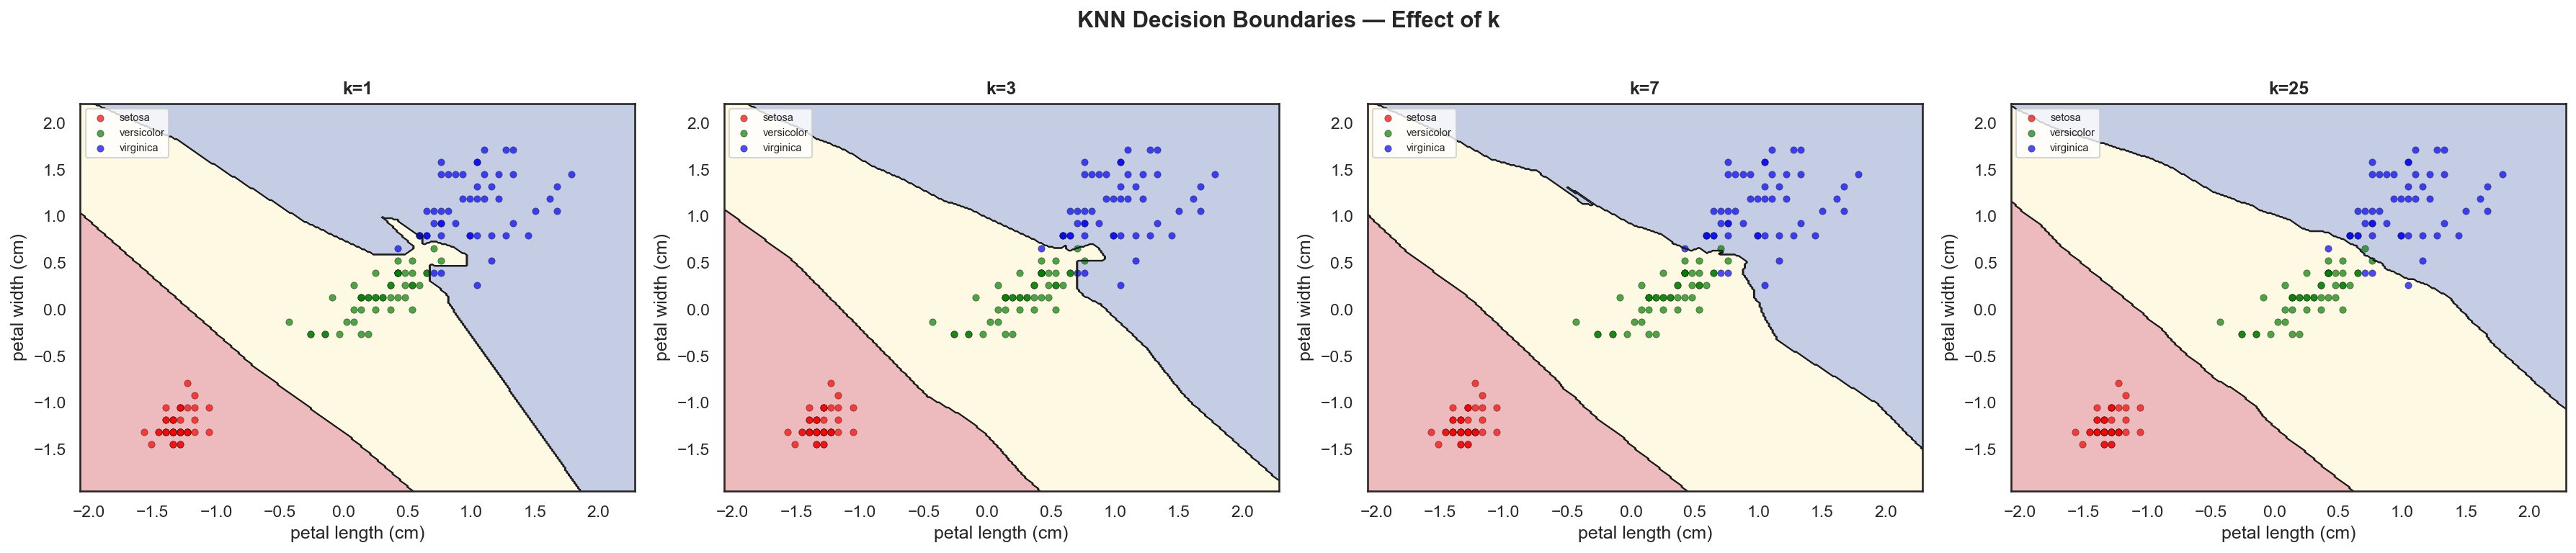

In [6]:
# Use only petal_length and petal_width for 2D visualization
X_2d = X_scaled[:, 2:4]  # petal_length (idx 2), petal_width (idx 3)
feature_pair = ["petal length (cm)", "petal width (cm)"]

k_values = [1, 3, 7, 25]
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, k in zip(axes, k_values):
    # Train on the 2D subset
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_2d, y)

    # Create mesh grid for the background
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    # Plot data points
    colors = ["red", "green", "blue"]
    for i, (name, color) in enumerate(zip(target_names, colors)):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, s=20,
                   edgecolors="k", linewidths=0.3, alpha=0.7)

    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])
    ax.set_title(f"k={k}", fontweight="bold")
    ax.legend(loc="upper left", fontsize=7)

fig.suptitle("KNN Decision Boundaries — Effect of k", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 What to Notice

- **k=1**: The boundary is extremely **jagged and complex**. Every single training point creates its own little "island" of influence. This is classic **overfitting** — the model memorizes the training data perfectly, including noise.
- **k=3**: Smoother boundaries that still capture the main class structure. A good balance.
- **k=7**: Even smoother. The boundaries become less sensitive to individual outlier points.
- **k=25**: Very smooth, almost linear boundaries. The model is averaging over 25 neighbors, so local detail is lost. This is **underfitting** — the decision regions may be too simple.

This is the **bias-variance trade-off** from the theory in action. In a later module, we'll learn systematic ways to find the optimal `k`.

---

## 6. Uniform vs. Distance Weighting

The theory introduces two neighbor weighting strategies:
- **`weights="uniform"`**: Every neighbor gets 1 vote (the default).
- **`weights="distance"`**: Closer neighbors get more influence (vote weight = $1/\text{distance}$).

Let's compare them:

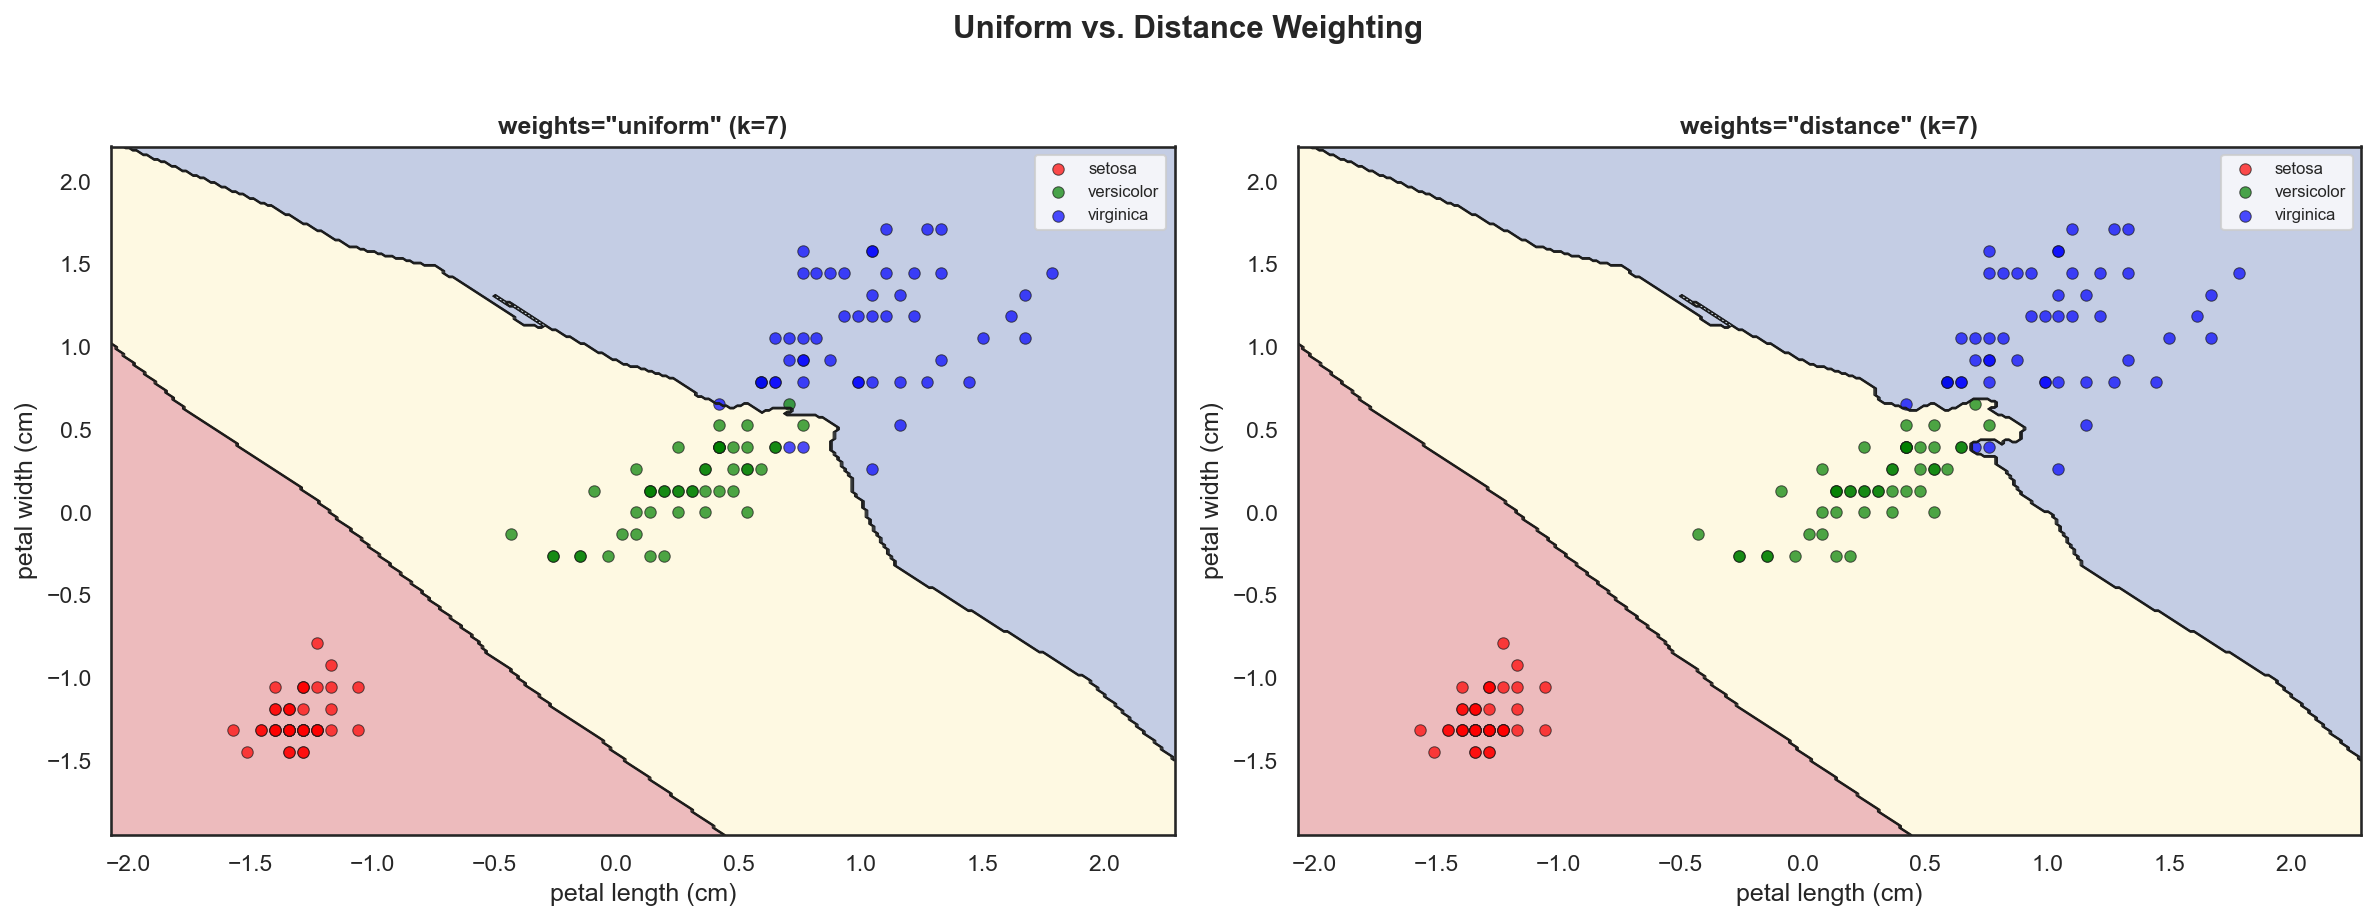

In [7]:
weight_options = ["uniform", "distance"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, w in zip(axes, weight_options):
    model = KNeighborsClassifier(n_neighbors=7, weights=w)
    model.fit(X_2d, y)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    for i, (name, color) in enumerate(zip(target_names, ["red", "green", "blue"])):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, s=30,
                   edgecolors="k", linewidths=0.5, alpha=0.7)

    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])
    ax.set_title(f'weights="{w}" (k=7)', fontweight="bold")
    ax.legend(fontsize=8)

fig.suptitle("Uniform vs. Distance Weighting", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 Uniform vs. Distance

- **`uniform`**: With k=7, all 7 neighbors have equal say. If 4 are versicolor and 3 are virginica, it predicts versicolor — even if the 3 virginica neighbors are much closer.
- **`distance`**: Closer neighbors carry more weight. This makes the boundary more responsive to the *nearest* points, which can recover some local detail even with a larger `k`.

Distance weighting is often a good default choice — it gets the smoothing benefit of a larger `k` without losing local sensitivity.

---

## 7. Why Scaling Matters: A Demonstration

The theory lists "Forgetting to Scale" as the **most important implementation detail** for KNN. Since KNN classifies based on *distance*, features with larger numeric ranges will completely dominate the distance calculation.

Let's prove it:

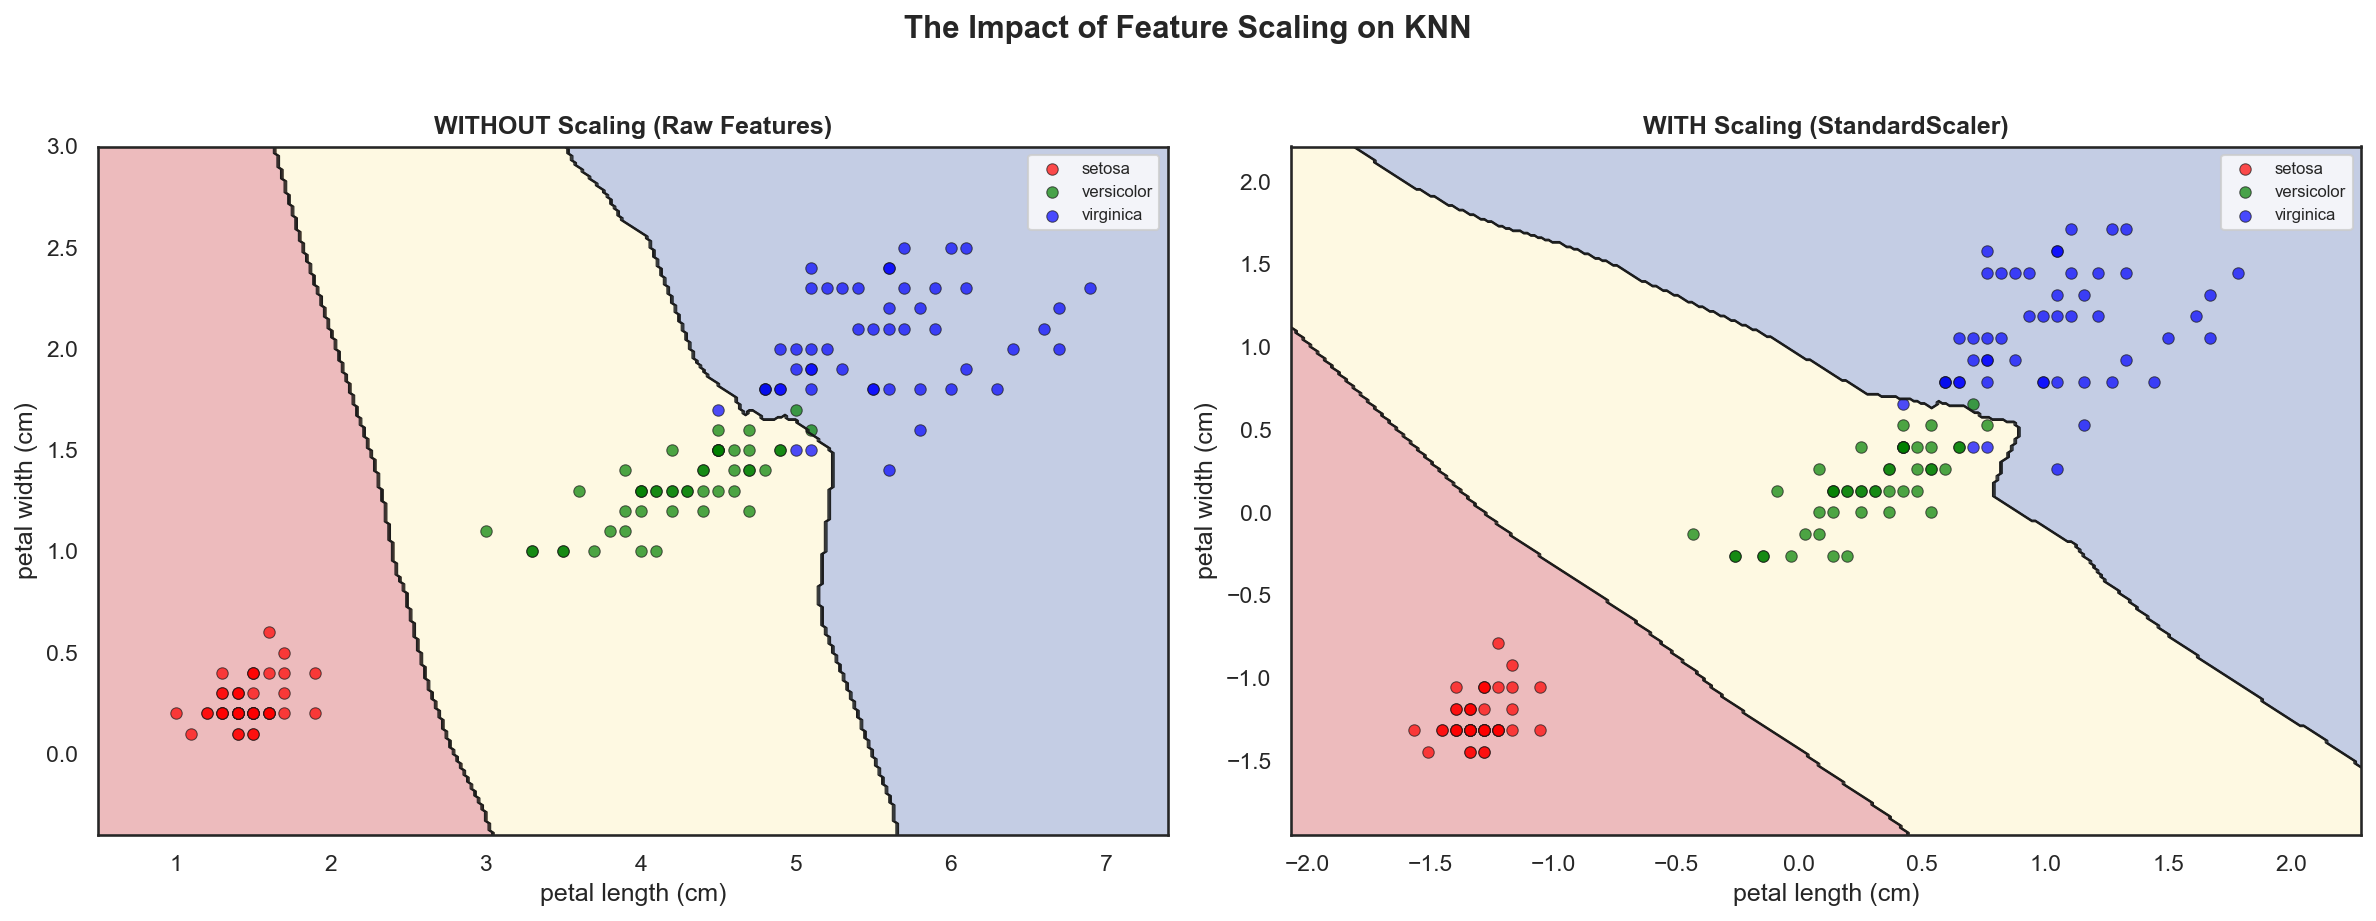

📌 With just two petal features, the ranges are similar (1–7 vs 0.1–2.5),
   so the visual difference is subtle. But imagine mixing 'Salary' (20,000–100,000)
   with 'Age' (20–60) — the salary feature would completely dominate the distance.
   Always scale your data before KNN — it's non-negotiable.


In [8]:
# Compare scaled vs. unscaled on petal features
X_2d_unscaled = X[:, 2:4]  # petal features, NOT scaled

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
titles = ["WITHOUT Scaling (Raw Features)", "WITH Scaling (StandardScaler)"]
datasets = [X_2d_unscaled, X_2d]

for ax, data, title in zip(axes, datasets, titles):
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(data, y)

    x_min, x_max = data[:, 0].min() - 0.5, data[:, 0].max() + 0.5
    y_min, y_max = data[:, 1].min() - 0.5, data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    for i, (name, color) in enumerate(zip(target_names, ["red", "green", "blue"])):
        mask = y == i
        ax.scatter(data[mask, 0], data[mask, 1], c=color, label=name, s=30,
                   edgecolors="k", linewidths=0.5, alpha=0.7)

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])
    ax.legend(fontsize=8)

fig.suptitle("The Impact of Feature Scaling on KNN", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 With just two petal features, the ranges are similar (1–7 vs 0.1–2.5),")
print("   so the visual difference is subtle. But imagine mixing 'Salary' (20,000–100,000)")
print("   with 'Age' (20–60) — the salary feature would completely dominate the distance.")
print("   Always scale your data before KNN — it's non-negotiable.")

---

## 8. Visualizing How KNN "Sees" the Data

Since KNN is all about **distance**, it's instructive to see *how the data is distributed* in the scaled feature space. Let's plot the pairwise distances between all points and color them by class:

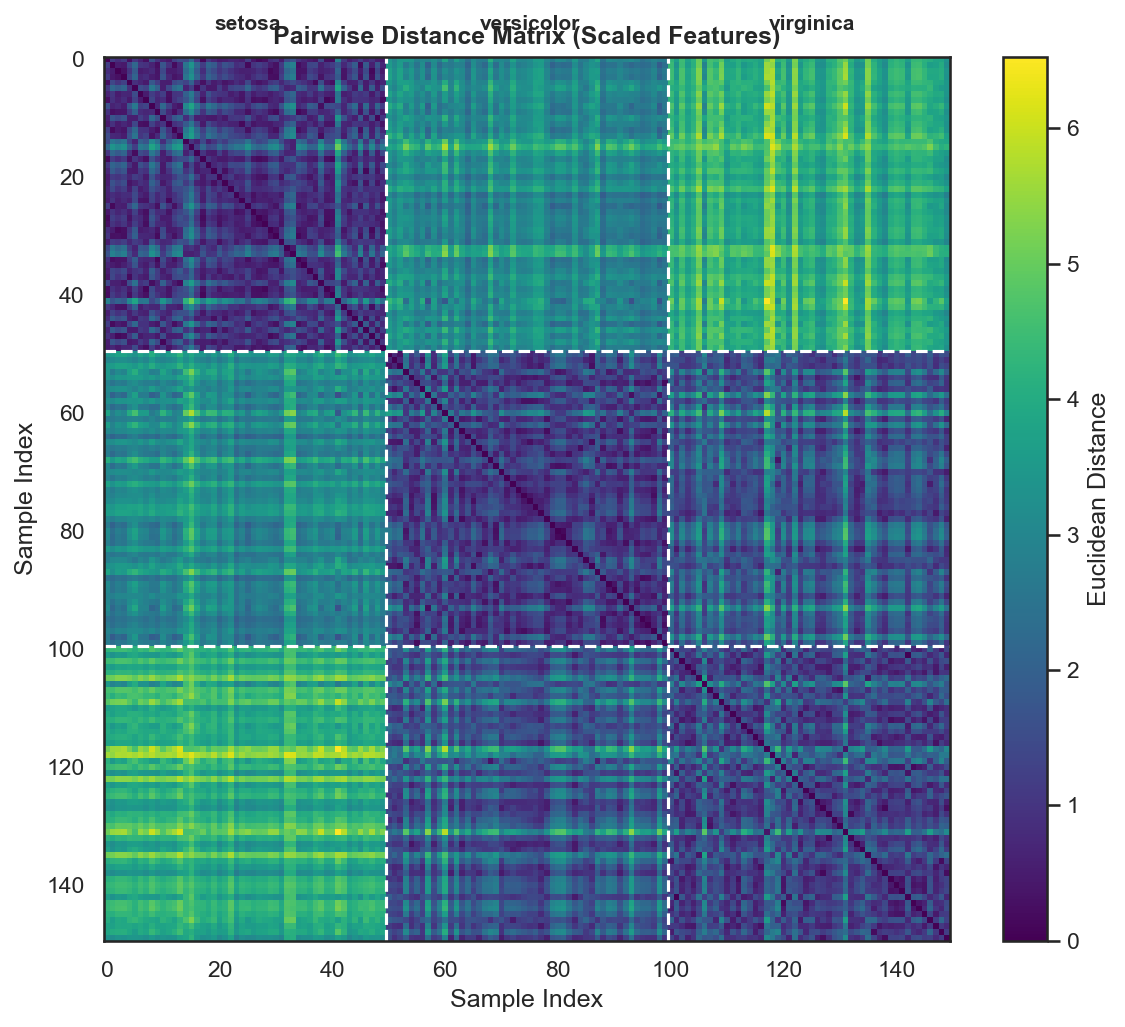

📌 Dark blocks on the diagonal = small intra-class distances (similar within class).
   The setosa block (0–49) is very dark and distinct — setosa is far from the others.
   The versicolor (50–99) and virginica (100–149) blocks overlap — these classes
   are closer together in feature space, which is why KNN sometimes confuses them.


In [9]:
from sklearn.metrics import pairwise_distances

# Compute pairwise Euclidean distances on the full 4D scaled data
dist_matrix = pairwise_distances(X_scaled, metric="euclidean")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(dist_matrix, cmap="viridis", aspect="auto")

# Add class boundaries
for boundary in [50, 100]:
    ax.axhline(y=boundary - 0.5, color="white", linewidth=1.5, linestyle="--")
    ax.axvline(x=boundary - 0.5, color="white", linewidth=1.5, linestyle="--")

# Label class regions
for i, name in enumerate(target_names):
    ax.text(i * 50 + 25, -5, name, ha="center", fontsize=10, fontweight="bold")

plt.colorbar(im, ax=ax, label="Euclidean Distance")
ax.set_title("Pairwise Distance Matrix (Scaled Features)", fontweight="bold")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Sample Index")
plt.tight_layout()
plt.show()

print("📌 Dark blocks on the diagonal = small intra-class distances (similar within class).")
print("   The setosa block (0–49) is very dark and distinct — setosa is far from the others.")
print("   The versicolor (50–99) and virginica (100–149) blocks overlap — these classes")
print("   are closer together in feature space, which is why KNN sometimes confuses them.")

---

## 9. The Lazy Learner: Prediction-Time Cost

The theory emphasizes that KNN is a **lazy learner** — it does no work during training and all the computation happens at prediction time. Let's verify this by timing both operations:

In [10]:
import time

model = KNeighborsClassifier(n_neighbors=5)

# Time the "training" (just storing data)
start = time.perf_counter()
for _ in range(1000):
    model.fit(X_scaled, y)
fit_time = (time.perf_counter() - start) / 1000

# Time the prediction (computing all distances)
start = time.perf_counter()
for _ in range(1000):
    model.predict(X_scaled)
predict_time = (time.perf_counter() - start) / 1000

print(f"Average .fit() time:     {fit_time*1000:.4f} ms  (just stores the data)")
print(f"Average .predict() time: {predict_time*1000:.4f} ms  (computes 150 × 150 distances)")
print(f"\nPrediction is ~{predict_time/fit_time:.1f}× slower than fitting.")
print(f"\n📌 For 150 samples, this is instant. But imagine 1 million training points —")
print(f"   each prediction would need to compute 1M distances. This is the O(N)")
print(f"   prediction cost from the theory. KNN doesn't scale well to large datasets.")

Average .fit() time:     0.1907 ms  (just stores the data)
Average .predict() time: 0.4534 ms  (computes 150 × 150 distances)

Prediction is ~2.4× slower than fitting.

📌 For 150 samples, this is instant. But imagine 1 million training points —
   each prediction would need to compute 1M distances. This is the O(N)
   prediction cost from the theory. KNN doesn't scale well to large datasets.


---

## 10. Exploring the Full API: `.kneighbors()` and `.predict_proba()`

scikit-learn's `KNeighborsClassifier` exposes useful methods beyond `.predict()`:

- **`.kneighbors(X)`**: Returns the distances and indices of the k nearest neighbors for each point.
- **`.predict_proba(X)`**: Returns the class "probabilities" (actually just the proportion of each class among the k neighbors).

Let's explore both:

In [11]:
# Use k=5 for this demo
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_scaled, y)

# Pick a borderline versicolor sample
sample_idx = 83
sample = X_scaled[sample_idx:sample_idx+1]

# Get neighbors
distances, indices = model.kneighbors(sample)

# Get "probabilities" (neighbor proportions)
proba = model.predict_proba(sample)

print(f"Query: sample {sample_idx} (true class: {target_names[y[sample_idx]]})")
print(f"Prediction: {target_names[model.predict(sample)[0]]}")
print(f"\n5 Nearest Neighbors:")
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    print(f"  #{rank}: index={idx}, distance={dist:.4f}, class={target_names[y[idx]]}")

print(f"\nClass probabilities (proportion of k neighbors):")
for name, prob in zip(target_names, proba[0]):
    bar = "█" * int(prob * 20)
    print(f"  {name:>12}: {prob:.2f}  {bar}")

print(f"\n📌 predict_proba() for KNN isn't a true probability — it's just the fraction")
print(f"   of neighbors belonging to each class. With k=5, probabilities are always")
print(f"   multiples of 0.20 (1/5 = 0.20, 2/5 = 0.40, etc.).")

Query: sample 83 (true class: versicolor)
Prediction: virginica

5 Nearest Neighbors:
  #1: index=83, distance=0.0000, class=versicolor
  #2: index=133, distance=0.4499, class=virginica
  #3: index=126, distance=0.4584, class=virginica
  #4: index=123, distance=0.4630, class=virginica
  #5: index=142, distance=0.4633, class=virginica

Class probabilities (proportion of k neighbors):
        setosa: 0.00  
    versicolor: 0.20  ████
     virginica: 0.80  ████████████████

📌 predict_proba() for KNN isn't a true probability — it's just the fraction
   of neighbors belonging to each class. With k=5, probabilities are always
   multiples of 0.20 (1/5 = 0.20, 2/5 = 0.40, etc.).


---

## Summary

In this lab, we learned how to use scikit-learn's `KNeighborsClassifier` for classification. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Load data | Iris dataset (150 flowers, 3 species) | `load_iris()` |
| **Scale features** | `StandardScaler` — mandatory for KNN | `StandardScaler().fit_transform()` |
| Build KNN | Trained `KNeighborsClassifier` with various k values | `KNeighborsClassifier(n_neighbors=...).fit(X, y)` |
| Inspect neighbors | Looked at which training points influence a prediction | `.kneighbors()` |
| Visualize boundaries | 2D decision regions for different k values | `.predict()` on a mesh grid |
| Effect of k | Showed overfitting (small k) vs. underfitting (large k) | `n_neighbors` parameter |
| Weighting schemes | Compared uniform vs. distance weighting | `weights` parameter |
| Scaling impact | Demonstrated that unscaled data distorts distances | Compared scaled vs. raw |
| Distance matrix | Visualized pairwise distances to understand class structure | `pairwise_distances()` |
| Lazy learning | Timed fit vs. predict to show prediction-time cost | `time.perf_counter()` |
| API exploration | Used `.kneighbors()` and `.predict_proba()` | Full API demo |

The key takeaways are:

1. **Feature scaling is mandatory** — KNN computes distances, so feature magnitude matters.
2. **`k` controls the bias-variance trade-off** — small k = complex boundary (overfit), large k = smooth boundary (underfit).
3. **Distance weighting** (`weights="distance"`) gives closer neighbors more influence and can be a good default.
4. **KNN is a lazy learner** — fast to train, slow to predict (O(N) per prediction).
5. **KNN is transparent** — you can inspect exactly which neighbors drove every prediction.
6. **KNN suffers from the Curse of Dimensionality** — it works best in low-to-medium dimensional spaces.

---

**Next:** [Naive Bayes Theory](./20_naive_bayes_theory.md)